##  Jour 3 — La Fonction de Coût (Loss Function)

###  Concept Théorique

La **fonction de coût** (ou *loss function*) mesure **à quel point notre modèle se trompe**. C'est le "bulletin de notes" du réseau. L'objectif de l'apprentissage est de **minimiser** cette fonction.

###  Intuition

Imaginez que vous jouez aux fléchettes :
- La **cible** est la vraie réponse ($y$)
- Votre **lancer** est la prédiction du modèle ($\hat{y}$)
- La **distance au centre** est la loss
- **Apprendre** = ajuster votre technique pour vous rapprocher du centre

###  Formules Essentielles

**MSE (Mean Squared Error) — pour la régression :**
$$\mathcal{L}_{\text{MSE}} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Binary Cross-Entropy — pour la classification binaire :**
$$\mathcal{L}_{\text{BCE}} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

###  Implémentation From Scratch


=== Démonstration MSE ===
  Prédiction: [0. 1. 0. 0.] → MSE = 1.0000
  Prédiction: [0.5 0.5 0.5 0.5] → MSE = 0.2500
  Prédiction: [0.8 0.2 0.8 0.8] → MSE = 0.0400
  Prédiction: [1. 0. 1. 1.] → MSE = 0.0000

=== Démonstration Cross-Entropy ===
  Prédiction: [0.01 0.99 0.01 0.01] → BCE = 4.6052
  Prédiction: [0.5 0.5 0.5 0.5] → BCE = 0.6931
  Prédiction: [0.8 0.2 0.8 0.8] → BCE = 0.2231
  Prédiction: [0.99 0.01 0.99 0.99] → BCE = 0.0101


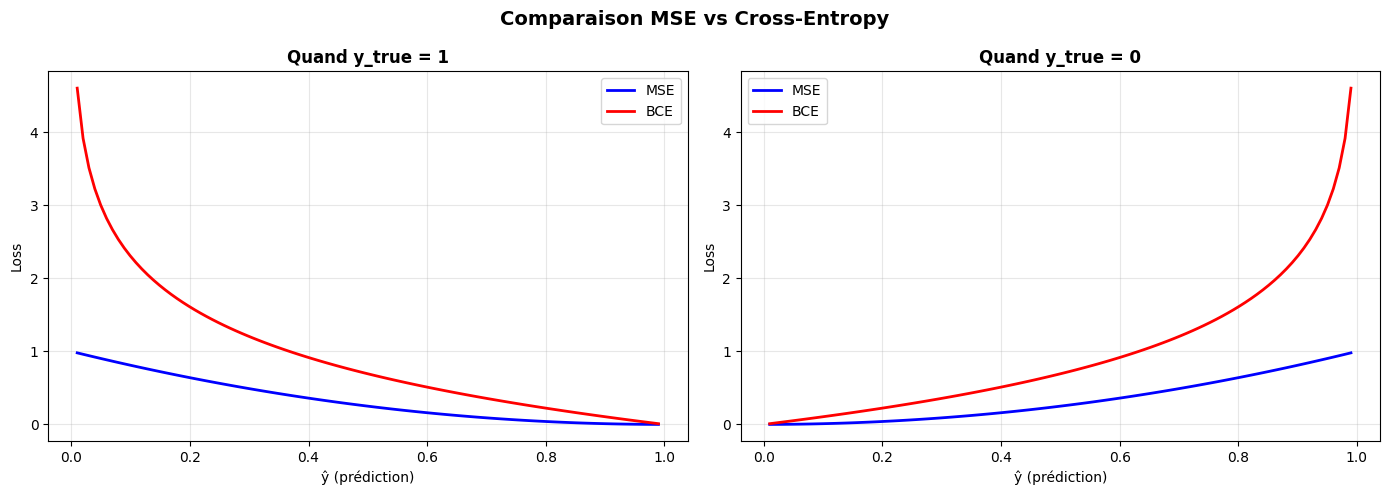

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# JOUR 3 : Les Fonctions de Coût (Loss Functions)
# ============================================================

# --- 1. Mean Squared Error (MSE) ---
def mse_loss(y_true, y_pred):
    """
    Erreur quadratique moyenne.
    Pénalise fortement les grandes erreurs (à cause du carré).

    Args:
        y_true: valeurs réelles (numpy array)
        y_pred: prédictions du modèle (numpy array)

    Returns:
        Scalaire : la loss moyenne
    """
    return np.mean((y_true - y_pred) ** 2)

def mse_gradient(y_true, y_pred):
    """
    Gradient de MSE par rapport à y_pred.
    C'est cette dérivée qu'on utilise pour la backpropagation.
    """
    n = len(y_true)
    return -2 / n * (y_true - y_pred)  # = 2/n * (y_pred - y_true)

# --- 2. Binary Cross-Entropy (BCE) ---
def binary_cross_entropy(y_true, y_pred):
    """
    Entropie croisée binaire.
    La loss standard pour la classification binaire.
    
    Note : on ajoute epsilon pour éviter log(0) = -inf
    """
    epsilon = 1e-15  # tout petit nombre pour la stabilité numérique
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # clamp entre ε et 1-ε
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

def bce_gradient(y_true, y_pred):
    """
    Gradient de BCE par rapport à y_pred.
    """
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return (-y_true / y_pred + (1 - y_true) / (1 - y_pred)) / len(y_true)

# --- Démonstration : voir comment la loss change ---
print("=== Démonstration MSE ===")
y_true = np.array([1.0, 0.0, 1.0, 1.0])

# Simuler des prédictions de plus en plus précises
predictions = [
    np.array([0.0, 1.0, 0.0, 0.0]),  # tout faux
    np.array([0.5, 0.5, 0.5, 0.5]),  # au milieu
    np.array([0.8, 0.2, 0.8, 0.8]),  # presque bon
    np.array([1.0, 0.0, 1.0, 1.0]),  # parfait
]

for pred in predictions:
    loss = mse_loss(y_true, pred)
    print(f"  Prédiction: {pred} → MSE = {loss:.4f}")

print("\n=== Démonstration Cross-Entropy ===")
for pred in predictions:
    pred_clipped = np.clip(pred, 0.01, 0.99)  # éviter 0 et 1 exacts
    loss = binary_cross_entropy(y_true, pred_clipped)
    print(f"  Prédiction: {pred_clipped} → BCE = {loss:.4f}")

# --- Visualisation : Loss en fonction de la prédiction ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_pred_range = np.linspace(0.01, 0.99, 100)

# Pour y_true = 1 : on veut que y_pred → 1
mse_when_true = (1 - y_pred_range) ** 2
bce_when_true = -np.log(y_pred_range)

axes[0].plot(y_pred_range, mse_when_true, 'b-', label='MSE', linewidth=2)
axes[0].plot(y_pred_range, bce_when_true, 'r-', label='BCE', linewidth=2)
axes[0].set_title("Quand y_true = 1", fontweight='bold')
axes[0].set_xlabel("ŷ (prédiction)")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pour y_true = 0 : on veut que y_pred → 0
mse_when_false = y_pred_range ** 2
bce_when_false = -np.log(1 - y_pred_range)

axes[1].plot(y_pred_range, mse_when_false, 'b-', label='MSE', linewidth=2)
axes[1].plot(y_pred_range, bce_when_false, 'r-', label='BCE', linewidth=2)
axes[1].set_title("Quand y_true = 0", fontweight='bold')
axes[1].set_xlabel("ŷ (prédiction)")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparaison MSE vs Cross-Entropy", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("loss_functions.png", dpi=150)
plt.show()


###  Résumé : Quelle loss pour quel problème ?

| Problème | Loss recommandée | Pourquoi |
|---|---|---|
| Régression (prédire un nombre) | MSE | Mesure la distance au carré |
| Classification binaire (oui/non) | Binary Cross-Entropy | Pénalise fortement les erreurs confiantes |
| Classification multi-classes | Categorical Cross-Entropy | Extension naturelle de BCE |